In [1]:
import mlflow
import numpy as np
import pylab as plt
import pandas as pd

In [2]:
!rsync -avz cluster.ies:/mnt/work/dhuseljic/mlflow/perf_dal /home/dhuseljic/mlflow

receiving incremental file list
perf_dal/
perf_dal/decision_flips.db

sent 2,435 bytes  received 39,376 bytes  27,874.00 bytes/sec
total size is 512,000  speedup is 12.25


In [6]:
client = mlflow.tracking.MlflowClient(tracking_uri=f'sqlite:///decision_flips.db')
experiment_id = client.get_experiment_by_name('decision_flips').experiment_id
# client = mlflow.tracking.MlflowClient(tracking_uri=f'sqlite:////home/dhuseljic/mlflow/perf_dal/decision_flips.db')
# experiment_id = client.get_experiment_by_name('decision_flips_0').experiment_id
query_list = [
    "parameter.min_train_samples = '10'",
    "parameter.max_train_samples = '100'",
]
runs = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
print('Found {} experiments'.format(len(runs)))

Found 1 experiments


In [9]:
from collections import defaultdict
all_results = defaultdict(list)
for run in runs:
    num_train_samples = [m.value for m in client.get_metric_history(run.info.run_id, 'num_train_samples')]
    num_new_samples = [m.value for m in client.get_metric_history(run.info.run_id, 'num_new_samples')]
    accuracy = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    accuracy_new = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy_new')]
    decision_flips = [m.value for m in client.get_metric_history(run.info.run_id, 'decision_flips')]

    all_results['num_train_samples'].append(num_train_samples)
    all_results['num_new_samples'].append(num_new_samples)
    all_results['accuracy'].append(accuracy)
    all_results['accuracy_new'].append(accuracy_new)
    all_results['decision_flips'].append(decision_flips)

In [11]:
num_train_samples = np.mean(all_results['num_train_samples'], 0)
num_new_samples = np.mean(all_results['num_new_samples'], 0)
accuracy = np.mean(all_results['accuracy'], 0)
accuracy_new = np.mean(all_results['accuracy_new'], 0)
decision_flips = np.mean(all_results['decision_flips'], 0)

In [15]:
num_train_samples
decision_flips

array([462., 310., 164., 176., 160.,  77.,  63.,  32.,  49.,  31.])

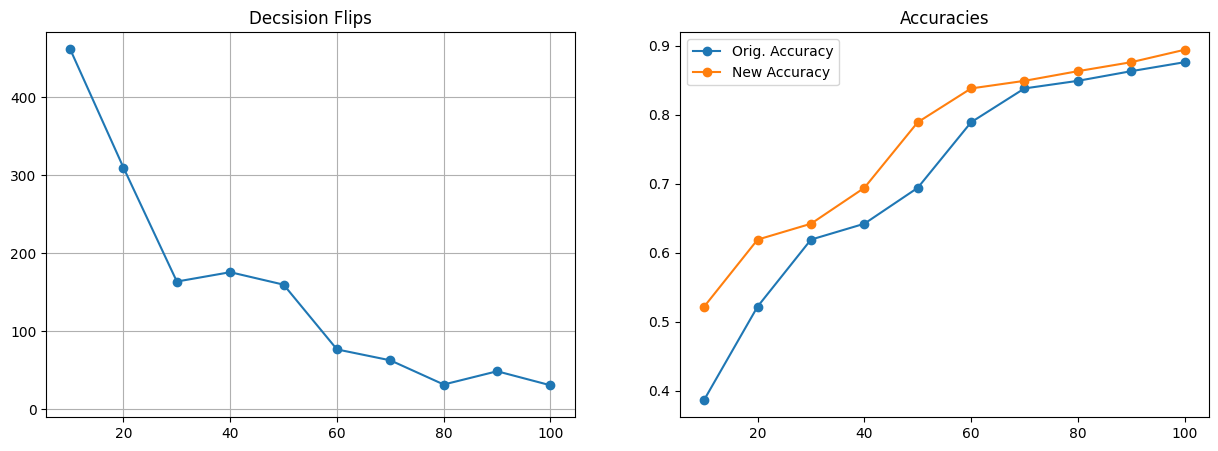

In [29]:
plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.title('Decsision Flips')
plt.plot(num_train_samples, decision_flips, '-o')
plt.ylim(bottom=-10)
plt.grid()

plt.subplot(122)
plt.title('Accuracies')
plt.plot(num_train_samples, accuracy, '-o', label='Orig. Accuracy')
plt.plot(num_train_samples, accuracy_new, '-o', label='New Accuracy')
plt.legend()
plt.show()